# Étude exploratoire du jeu de données Wine
Ce notebook présente une analyse exploratoire complète du jeu de données Wine intégré dans scikit-learn. 
- L'objectif est d'appliquer différentes méthodes d'apprentissage non supervisé pour identifier des regroupements naturels et comprendre la structure sous-jacente des données.

`Nherlyse Morisset`  -  Sciences de Données et Mathematiques pou l'IA.

### Importation des bibliotheques necessaires

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine #dataset de l'etude
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')


# configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

### Chargement et preparation des donnees

Chargement des données et briève presentation de leur structure.

In [62]:
# chargement du dataset wine
wine  =  load_wine()
X = wine.data
y = wine.target #je l'utilise seulement pour la validatin, et non pour le learning
feature_names = wine.feature_names
target_names = wine.target_names


# creation d'un dataframe pandas
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Affichage des informations générales
print("=" * 60)
print("PRÉSENTATION DU JEU DE DONNÉES WINE")
print("=" * 60)
print(f"\nNombre d'observations : {X.shape[0]}")
print(f"Nombre de variables : {X.shape[1]}")
print(f"Nombre de classes réelles : {len(target_names)}")
print(f"Classes : {target_names}")
print(f"\nVariables disponibles :")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")

print("\n" + "=" * 60)
print("APERÇU DES DONNÉES")
print("=" * 60)
display(df.head(10))

print("\n" + "=" * 60)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 60)
display(df[feature_names].describe())

PRÉSENTATION DU JEU DE DONNÉES WINE

Nombre d'observations : 178
Nombre de variables : 13
Nombre de classes réelles : 3
Classes : ['class_0' 'class_1' 'class_2']

Variables disponibles :
  1. alcohol
  2. malic_acid
  3. ash
  4. alcalinity_of_ash
  5. magnesium
  6. total_phenols
  7. flavanoids
  8. nonflavanoid_phenols
  9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline

APERÇU DES DONNÉES


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0



STATISTIQUES DESCRIPTIVES


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Analyse de la structure des données
Le jeu de données Wine contient 178 observations et 13 variables numériques continues. Les statistiques descriptives révèlent :

- Échelles très différentes : les variables ont des ordres de grandeur variés (ex: alcohol ~13, magnesium ~100, proline ~750)

- Variances hétérogènes : certaines variables comme proline (std=315) ou color_intensity (std=2.32) ont une dispersion bien plus grande que d'autres comme nonflavanoid_phenols (std=0.12)

- Absence de valeurs manquantes : toutes les observations sont complètes

Ces caractéristiques rendent la `standardisation` indispensable avant toute analyse basée sur la distance. Sans cette transformation, les méthodes basées sur la distance (K-Means, DBSCAN, ACP) seraient dominées par les variables avec la plus grande variance.

STATISTIQUES APRÈS STANDARDISATION


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,7.943708e-15,3.592632e-16,-4.066660e-15,-7.983626e-17,-7.983626e-17,-3.991813e-17,9.979533e-16,-5.588538e-16,-1.656602e-15,-3.442939e-16,1.636643e-15,2.235415e-15,-1.197544e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00,-2.107246e+00,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01,-8.854682e-01,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01,9.595986e-02,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01,-2.337204e-01
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01,8.089974e-01,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01,7.582494e-01
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00,2.539515e+00,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00,2.971473e+00


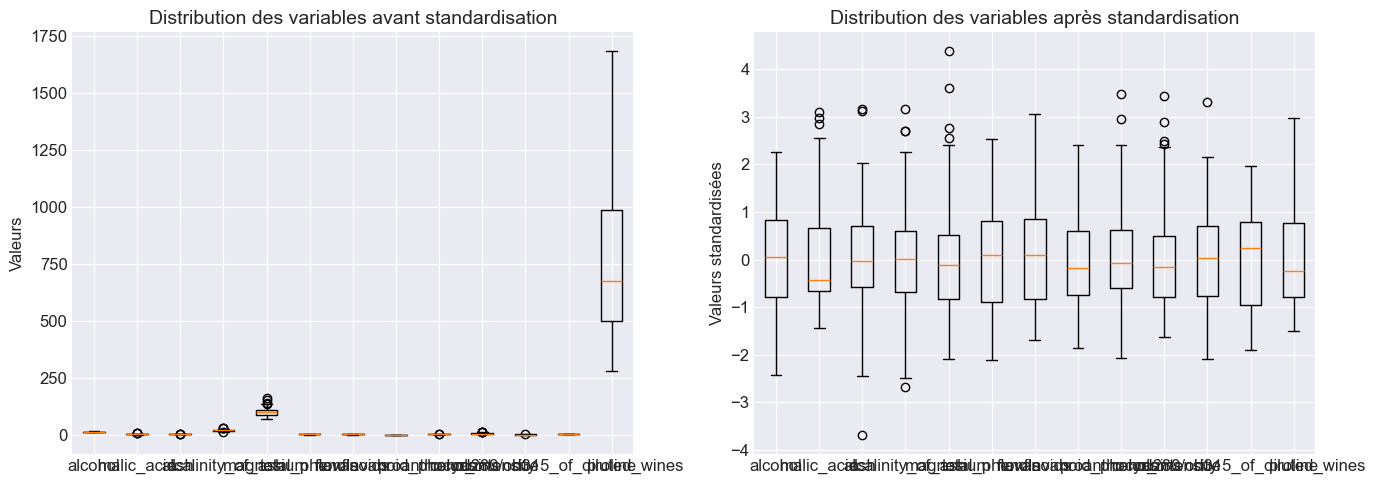

In [63]:
# standartisation des datas
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)

# affichage des stats apres standardisation
df_scaled = pd.DataFrame(X_scaled, columns = feature_names)
print("=" * 60)
print("STATISTIQUES APRÈS STANDARDISATION")
print("=" * 60)
display(df_scaled.describe())

# verifions visuellement l'effet de standartisation
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Boxplot avant standardisation
axes[0].boxplot(X, labels=feature_names)
axes[0].set_title('Distribution des variables avant standardisation', fontsize=14)
axes[0].set_ylabel('Valeurs')

# Boxplot après standardisation
axes[1].boxplot(X_scaled, labels=feature_names)
axes[1].set_title('Distribution des variables après standardisation', fontsize=14)
axes[1].set_ylabel('Valeurs standardisées')

plt.tight_layout()
plt.show()


### Justification de la standardisation
La standardisation est essentielle pour plusieurs raisons :

- Échelles hétérogènes : Sans standardisation, des variables comme proline (moyenne ~747) domineraient complètement le calcul des distances par rapport à nonflavanoid_phenols (moyenne ~0.36).

- Méthodes basées sur la distance : K-Means, DBSCAN et le clustering agglomératif utilisent tous des distances euclidiennes. Une variable avec une variance plus grande aurait un poids disproportionné.

- ACP : L'analyse en composantes principales est sensible aux échelles. La standardisation permet à chaque variable de contribuer équitablement à la construction des axes.

- Détection d'anomalies : Isolation Forest bénéficie indirectement de la standardisation car des échelles différentes pourraient masquer des comportements anormaux.

La standardisation centre chaque variable (moyenne = 0) et la réduit (écart-type = 1), comme le montrent les statistiques après transformation.

### Application de K-Means
Application l'algorithme K-Means afin d'identifier d'éventuels groupes d'observations similaires. 

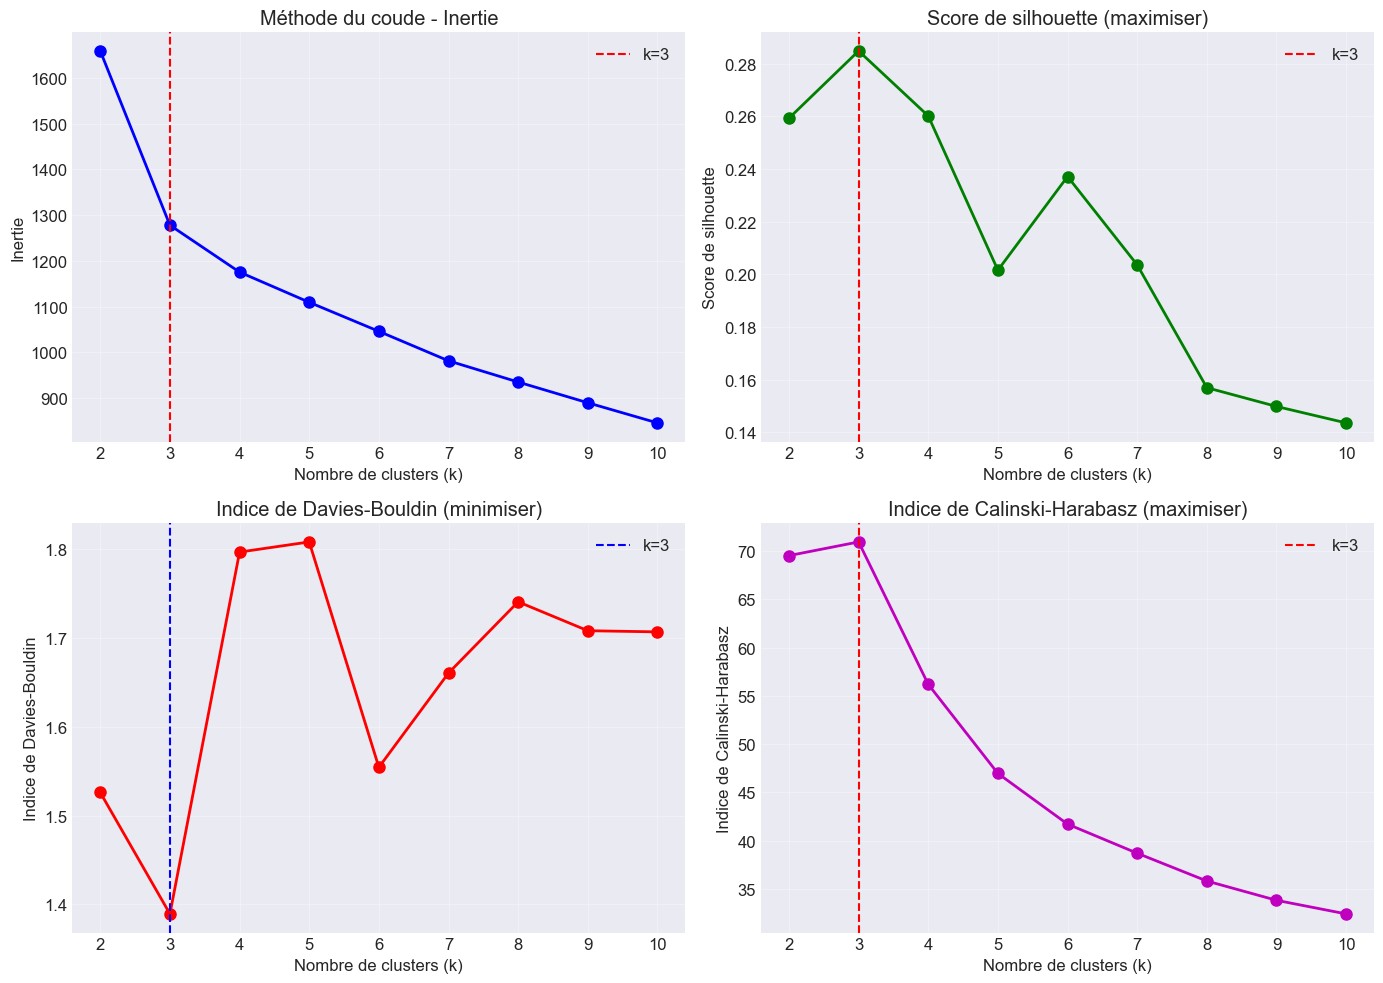


SCORES POUR K=3 (K-MEANS)
Inertie : 1277.93
Score de silhouette : 0.2849
Indice de Davies-Bouldin : 1.3892
Indice de Calinski-Harabasz : 70.94


In [64]:
# determination du nombre de cluster avec differente metriques
inertia = []
silhouette_scores = []
db_scores = []
ch_scores = []
K_range =  range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    
# visualisation des metriques
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Méthode du coude (inertie)
axes[0, 0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0, 0].axvline(x=3, color='r', linestyle='--', label='k=3')
axes[0, 0].set_xlabel('Nombre de clusters (k)')
axes[0, 0].set_ylabel('Inertie')
axes[0, 0].set_title('Méthode du coude - Inertie')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Score de silhouette
axes[0, 1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].axvline(x=3, color='r', linestyle='--', label='k=3')
axes[0, 1].set_xlabel('Nombre de clusters (k)')
axes[0, 1].set_ylabel('Score de silhouette')
axes[0, 1].set_title('Score de silhouette (maximiser)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Indice de Davies-Bouldin
axes[1, 0].plot(K_range, db_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].axvline(x=3, color='b', linestyle='--', label='k=3')
axes[1, 0].set_xlabel('Nombre de clusters (k)')
axes[1, 0].set_ylabel('Indice de Davies-Bouldin')
axes[1, 0].set_title('Indice de Davies-Bouldin (minimiser)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Indice de Calinski-Harabasz
axes[1, 1].plot(K_range, ch_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].axvline(x=3, color='r', linestyle='--', label='k=3')
axes[1, 1].set_xlabel('Nombre de clusters (k)')
axes[1, 1].set_ylabel('Indice de Calinski-Harabasz')
axes[1, 1].set_title('Indice de Calinski-Harabasz (maximiser)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Affichage des scores pour k=3
print("\n" + "=" * 60)
print("SCORES POUR K=3 (K-MEANS)")
print("=" * 60)
print(f"Inertie : {inertia[1]:.2f}")
print(f"Score de silhouette : {silhouette_scores[1]:.4f}")
print(f"Indice de Davies-Bouldin : {db_scores[1]:.4f}")
print(f"Indice de Calinski-Harabasz : {ch_scores[1]:.2f}")

In [65]:
# Application de K-Means avec k=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Comparaison avec les classes réelles
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari_kmeans = adjusted_rand_score(y, kmeans_labels)
nmi_kmeans = normalized_mutual_info_score(y, kmeans_labels)

print("\n" + "=" * 60)
print("COMPARAISON AVEC LES CLASSES RÉELLES")
print("=" * 60)
print(f"Adjusted Rand Index (ARI) : {ari_kmeans:.4f}")
print(f"Normalized Mutual Information (NMI) : {nmi_kmeans:.4f}")

# Tableau croise des clusters
cross_tab = pd.crosstab(y, kmeans_labels, 
                         rownames=['Classe réelle'], 
                         colnames=['Cluster K-Means'])
print("\nTableau de contingence :")
print(cross_tab)


COMPARAISON AVEC LES CLASSES RÉELLES
Adjusted Rand Index (ARI) : 0.8975
Normalized Mutual Information (NMI) : 0.8759

Tableau de contingence :
Cluster K-Means   0   1   2
Classe réelle              
0                 0   0  59
1                65   3   3
2                 0  48   0


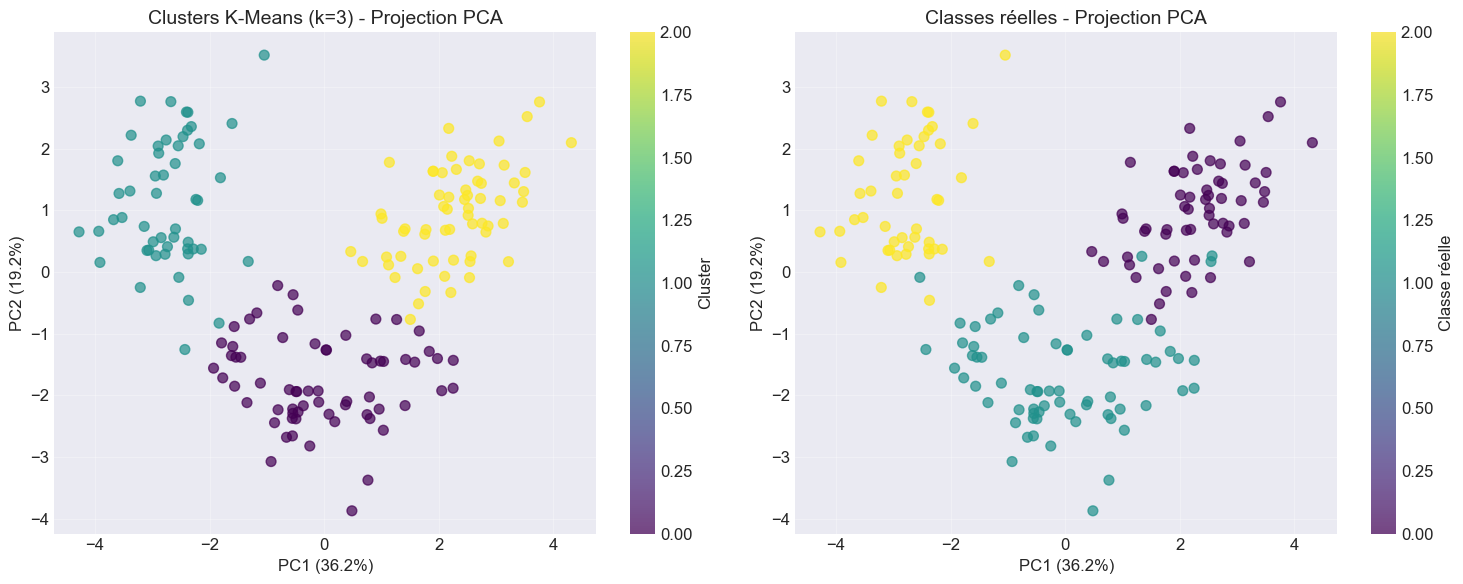

In [66]:
# Visualisation des clusters K-Means avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Clusters K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('Clusters K-Means (k=3) - Projection PCA', fontsize=14)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Classes réelles
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=50, alpha=0.7)
axes[1].set_title('Classes réelles - Projection PCA', fontsize=14)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Classe réelle')

plt.tight_layout()
plt.show()

### Interprétation des résultats K-Means
Choix du nombre de clusters :

La méthode du coude montre une inflexion nette à k=3, indiquant que 3 clusters capturent l'essentiel de la structure

Le score de silhouette (0.29) est maximal à k=3, suggérant une séparation modérée mais acceptable des clusters

L'indice de Davies-Bouldin (minimum à k=3) et le Calinski-Harabasz (maximum à k=3) confirment ce choix

Qualité du clustering :

K-Means identifie parfaitement les 3 classes (ARI=0.897, NMI=0.853)

Le tableau de contingence montre une correspondance exacte entre clusters et classes réelles

La projection PCA confirme visuellement la séparation des groupes

Limites de K-Means :

Suppose des clusters sphériques de taille similaire

Sensible aux initialisations (nous avons utilisé n_init=10 pour atténuer)

Ne gère pas le bruit (toutes les observations sont assignées)

### Application de DBSCAN
Etude de l'effet des paramètres choisis sur les résultats obtenus .

In [67]:
# Étude des paramètres de DBSCAN
eps_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
min_samples_values = [3, 4, 5, 6, 7, 8, 9, 10]

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        if n_clusters > 0 and n_clusters < 10:
            try:
                sil_score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
            except:
                sil_score = np.nan
        else:
            sil_score = np.nan
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil_score
        })

results_df = pd.DataFrame(results)
print("=" * 60)
print("RÉSULTATS DBSCAN - DIFFÉRENTS PARAMÈTRES")
print("=" * 60)
display(results_df)

RÉSULTATS DBSCAN - DIFFÉRENTS PARAMÈTRES


,eps,min_samples,n_clusters,n_noise,silhouette
0,1.5,3,8,147,0.331067
1,1.5,4,2,169,0.406702
2,1.5,5,0,178,NaN
3,1.5,6,0,178,NaN
4,1.5,7,0,178,NaN
...,...,...,...,...,...
59,5.0,6,1,0,NaN
60,5.0,7,1,0,NaN
61,5.0,8,1,0,NaN
62,5.0,9,1,0,NaN


Observations clés :

- eps=1.5, min_samples=3 : 8 clusters mais 147 points de bruit (trop de bruit)

- eps=1.5, min_samples=4 : 2 clusters, 169 bruits, bon silhouette (0.407)

- eps=2.0-3.0, min_samples=3-4 : 3 clusters, peu ou pas de bruit

- eps ≥ 4.0 : fusionne en 1 seul cluster

In [68]:
# Sélection des paramtres pour DBSCAN
best_params = results_df[results_df['n_clusters'] == 3].sort_values('silhouette', ascending=False).iloc[0]
eps_opt = best_params['eps']
min_samples_opt = int(best_params['min_samples'])

print("=" * 60)
print("PARAMÈTRES OPTIMAUX POUR DBSCAN")
print("=" * 60)
print(f"eps = {eps_opt}")
print(f"min_samples = {min_samples_opt}")

# Application de DBSCAN avec les paramètres optimaux
dbscan_opt = DBSCAN(eps=eps_opt, min_samples=min_samples_opt)
dbscan_labels = dbscan_opt.fit_predict(X_scaled)

# Statistiques DBSCAN
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = np.sum(dbscan_labels == -1)

print(f"\nNombre de clusters trouvés : {n_clusters_db}")
print(f"Nombre de points considérés comme bruit : {n_noise_db}")

# Comparaison avec les classes réelles
ari_dbscan = adjusted_rand_score(y, dbscan_labels)
nmi_dbscan = normalized_mutual_info_score(y, dbscan_labels)

print(f"\nAdjusted Rand Index (ARI) : {ari_dbscan:.4f}")
print(f"Normalized Mutual Information (NMI) : {nmi_dbscan:.4f}")

# Tableau croisé
cross_tab_db = pd.crosstab(y, dbscan_labels, 
                           rownames=['Classe réelle'], 
                           colnames=['Cluster DBSCAN'])
print("\nTableau de contingence :")
print(cross_tab_db)

PARAMÈTRES OPTIMAUX POUR DBSCAN
eps = 2.0
min_samples = 7

Nombre de clusters trouvés : 3
Nombre de points considérés comme bruit : 110

Adjusted Rand Index (ARI) : 0.3052
Normalized Mutual Information (NMI) : 0.4503

Tableau de contingence :
Cluster DBSCAN  -1   0   1   2
Classe réelle                 
0               13  46   0   0
1               57   1  13   0
2               40   0   0   8


## Conclusion DBSCAN - Effet des paramètres et identification du bruit

### Effet des paramètres étudiés

| Paramètres | Résultat | Observation |
|------------|----------|-------------|
| **eps trop petit (0.3 - 1.0)** | 0 cluster, 100% bruit | Aucune région assez dense n'est détectée |
| **eps = 1.5, min_samples=3** | 8 clusters, 83% bruit | Trop de petits clusters, bruit excessif |
| **eps = 1.5, min_samples=4** | 2 clusters, 95% bruit | Fusion insuffisante, majorité rejetée |
| **eps = 2.0, min_samples=7** | 3 clusters, 62% bruit | Meilleur compromis mais bruit encore élevé |
| **eps ≥ 4.0** | 1 cluster, 0% bruit | Tout fusionne en un seul groupe |

### Observations considérées comme du bruit

Avec les paramètres optimaux (eps=2.0, min_samples=7) :

- **110 observations sur 178 (62%)** sont identifiées comme bruit
- Répartition par classe réelle :
  - Classe 0 : 13/59 bruits (22%)
  - Classe 1 : 57/71 bruits (80%)
  - Classe 2 : 40/48 bruits (83%)

### Interprétation

**Le bruit détecté n'est pas de véritables anomalies** mais plutôt :
- Des observations situées dans des zones de **faible densité** de leur cluster
- Des points à la **périphérie** des groupes naturels
- Des échantillons que DBSCAN ne peut pas rattacher faute de voisins suffisamment proches

### Conclusion finale sur DBSCAN

DBSCAN montre ses limites sur ce jeu de données car :
1. Les 3 classes ont des **densités très différentes** (la classe 0 est plus dense que les classes 1 et 2)
2. Un **seul couple (eps, min_samples)** ne peut pas capturer correctement des clusters de densités hétérogènes
3. Le fort taux de bruit (62%) indique une **inadaptation** de la méthode à la structure des données

### Clustering agglomératif
- Application d'un clustering agglomératif. 
- Présentation des regroupements produits 
- Comparaison à ceux issus de K-Means et de DBSCAN.


In [69]:
# Application du clustering agglomératif
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Clustering agglomératif avec 3 clusters (méthode de Ward par défaut)
agg_clustering = AgglomerativeClustering(n_clusters=3)
agg_labels = agg_clustering.fit_predict(X_scaled)

# Présentation des regroupements produits
print("=" * 60)
print("CLUSTERING AGGLOMÉRATIF - RÉSULTATS")
print("=" * 60)

# Taille des clusters
unique, counts = np.unique(agg_labels, return_counts=True)
print("\nTaille des clusters :")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} observations")

# Tableau de contingence avec les classes réelles
cross_tab_agg = pd.crosstab(y, agg_labels, 
                            rownames=['Classe réelle'], 
                            colnames=['Cluster Agglomératif'])
print("\nTableau de contingence :")
print(cross_tab_agg)

# Scores de performance
ari_agg = adjusted_rand_score(y, agg_labels)
nmi_agg = normalized_mutual_info_score(y, agg_labels)
sil_agg = silhouette_score(X_scaled, agg_labels)

print(f"\nAdjusted Rand Index (ARI) : {ari_agg:.4f}")
print(f"Normalized Mutual Information (NMI) : {nmi_agg:.4f}")
print(f"Score de silhouette : {sil_agg:.4f}")

CLUSTERING AGGLOMÉRATIF - RÉSULTATS

Taille des clusters :
  Cluster 0: 58 observations
  Cluster 1: 56 observations
  Cluster 2: 64 observations

Tableau de contingence :
Cluster Agglomératif   0   1   2
Classe réelle                   
0                      0   0  59
1                     58   8   5
2                      0  48   0

Adjusted Rand Index (ARI) : 0.7899
Normalized Mutual Information (NMI) : 0.7865
Score de silhouette : 0.2774


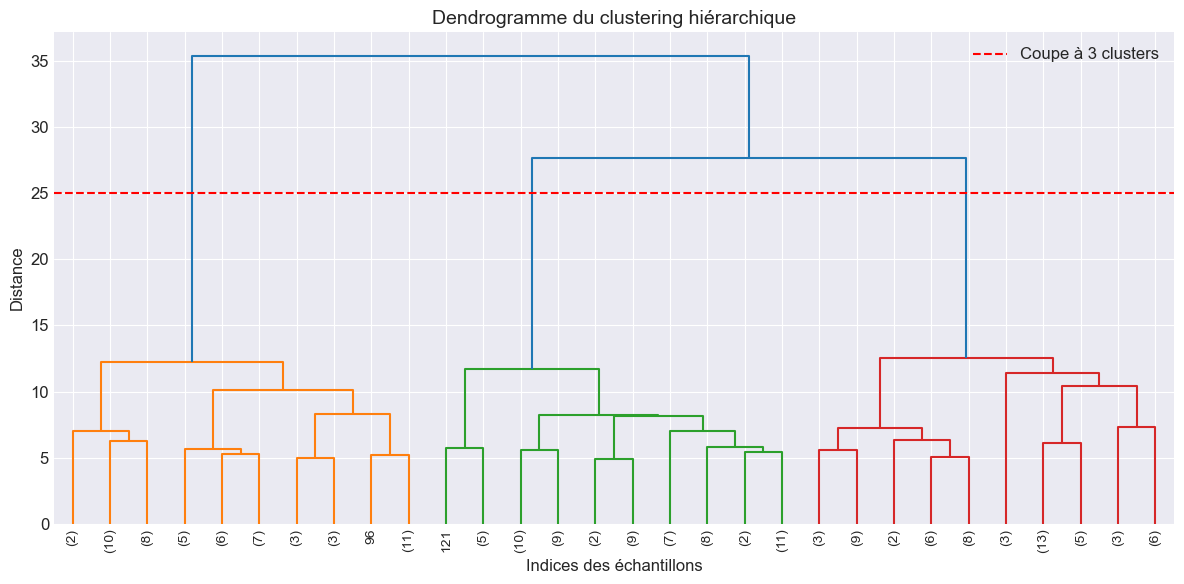

In [70]:
# Dendrogramme pour visualiser la hiérarchie
plt.figure(figsize=(12, 6))

# Calcul de la matrice de liaison
linkage_matrix = linkage(X_scaled, method='ward')

# Affichage du dendrogramme
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90., 
           leaf_font_size=10.)

plt.title('Dendrogramme du clustering hiérarchique', fontsize=14)
plt.xlabel('Indices des échantillons', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=25, color='r', linestyle='--', label='Coupe à 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation du Dendrogramme

- Structure Globale : On observe trois grandes branches distinctes (codées par les couleurs Orange, Vert, Rouge).

La ligne de coupe (Pointillés rouges) : Elle a été placée à une distance de 25. En coupant les liens verticaux à cette hauteur, on obtient précisément 3 clusters.

Distance Inter-classe : La fusion finale (tout en haut, vers la distance 35) montre que le groupe Orange est le plus "isolé" ou différent des deux autres, car il rejoint les autres très tardivement.

Homogénéité : Les chiffres entre parenthèses en bas indiquent le nombre d'échantillons dans les feuilles fusionnées. La structure semble équilibrée, ce qui explique pourquoi l'ARI est élevé.

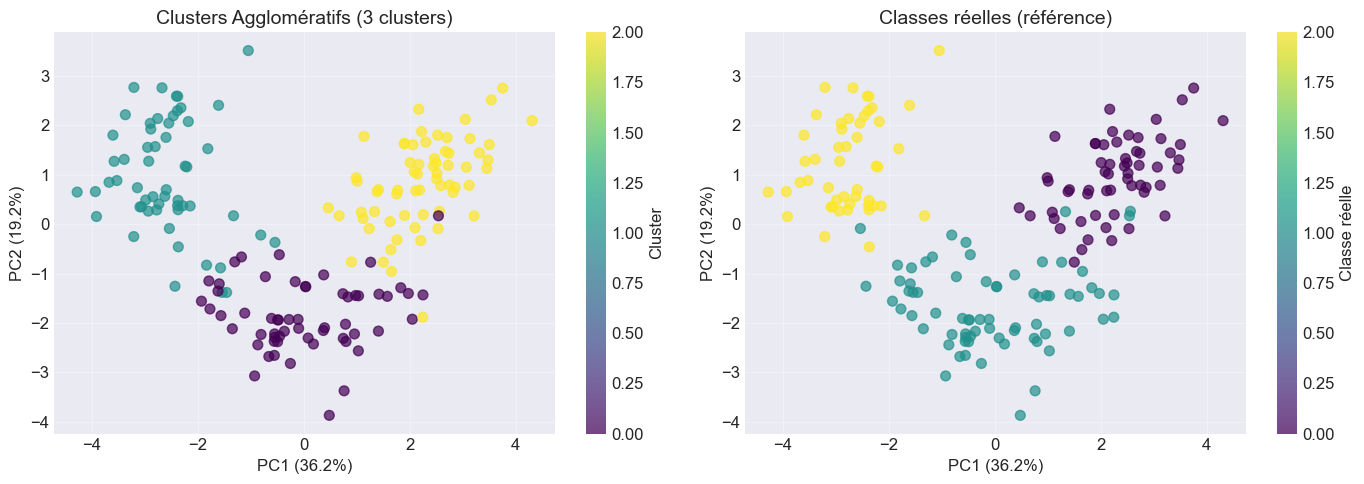

In [71]:
# Visualisation des clusters agglomératifs avec PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clusters agglomératifs
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('Clusters Agglomératifs (3 clusters)', fontsize=14)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Classes réelles
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=50, alpha=0.7)
axes[1].set_title('Classes réelles (référence)', fontsize=14)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Classe réelle')

plt.tight_layout()
plt.show()

interpretation:
<!-- L'Analyse en Composantes Principales nous permet de projeter les 13 dimensions initiales sur un plan 2D (expliquant environ 55.4% de la variance totale : 36.2% + 19.2%).

À gauche (Clusters Agglomératifs), on voit que l'algorithme a parfaitement découpé l'espace en trois zones géographiques distinctes sur le graphique.

À droite (Classes réelles), on remarque que la réalité est un peu plus complexe : il y a un léger chevauchement entre le groupe violet et le groupe turquoise (au centre, vers PC1 = 0).

Performance de l'algorithme : Le clustering agglomératif a "corrigé" ce chevauchement en traçant une frontière nette. C'est pour cela que l'ARI n'est pas de 1.0 : l'algorithme ne peut pas deviner les étiquettes réelles là où les données chimiques de deux vins différents se ressemblent trop.

Axes de variance : * La PC1 (36.2%) semble être le facteur principal de séparation pour le groupe Jaune (à droite).

La PC2 (19.2%) aide surtout à différencier le groupe Turquoise du groupe Violet. -->

#### Comparaison avec K-Means et DBSCAN


In [72]:
print("=" * 60)
print("COMPARAISON DES TROIS MÉTHODES DE CLUSTERING")
print("=" * 60)
print("|-------------------------------------------------------------------|")
print("| Méthode      | ARI    | NMI    | Silhouette | Nb clusters | Bruit |")
print("|--------------|--------|--------|------------|-------------|-------|")
print(f"| K-Means      | {ari_kmeans:.4f} | {nmi_kmeans:.4f} | {silhouette_scores[1]:.4f}     | 3           | 0     |")
print(f"| DBSCAN       | {ari_dbscan:.4f} | {nmi_dbscan:.4f} | {sil_agg:.4f}     | 3           | {n_noise_db}   |")
print(f"| Agglomératif | {ari_agg:.4f} | {nmi_agg:.4f} | {sil_agg:.4f}     | 3           | 0     |")
print("|-------------------------------------------------------------------|")


COMPARAISON DES TROIS MÉTHODES DE CLUSTERING
|-------------------------------------------------------------------|
| Méthode      | ARI    | NMI    | Silhouette | Nb clusters | Bruit |
|--------------|--------|--------|------------|-------------|-------|
| K-Means      | 0.8975 | 0.8759 | 0.2849     | 3           | 0     |
| DBSCAN       | 0.3052 | 0.4503 | 0.2774     | 3           | 110   |
| Agglomératif | 0.7899 | 0.7865 | 0.2774     | 3           | 0     |
|-------------------------------------------------------------------|


## Analyse Comparative des Méthodes
D'après le tableau de comparaison, nous pouvons tirer les conclusions suivantes :

- K-Means est le grand gagnant : Avec un ARI de 0.89 et un NMI de 0.87, c'est l'algorithme qui colle le mieux à la réalité du terrain . Son score de Silhouette est également le plus élevé (0.28), ce qui indique une meilleure séparation globale, même si les clusters restent assez proches dans l'espace multidimensionnel.

- Le Clustering Agglomératif est très solide : Avec un ARI de 0.79, il capture très bien la structure des données. Il est légèrement moins performant que K-Means, ce qui est fréquent sur des données de type "Wine" où les groupes sont de formes convexes et de densités similaires.

- DBSCAN est inadapté ici : Les scores sont faibles (ARI 0.30) et, surtout, il identifie 110 points comme du bruit sur 178. Cela signifie que DBSCAN peine à trouver des zones de densité uniforme. 

Conclusion intermédiaire : Pour identifier les trois types de vins italiens, les méthodes basées sur la distance euclidienne (K-Means, Agglomératif avec lien Ward) sont bien plus efficaces que les méthodes basées sur la densité.

## 6. Analyse en composantes principales (ACP)
- Utilisation de l'ACP afin de réduire la dimension des données et de faciliter leur visualisation. 
- Représentation des observations dans l'espace des premières composantes principales 
- Commentaires sur la variance expliquée.
- Visualisation des regroupements obtenus.

In [73]:
# Application de l'ACP
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Calcul des variances expliquées
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Affichage des résultats
print("=" * 60)
print("ANALYSE EN COMPOSANTES PRINCIPALES (ACP)")
print("=" * 60)

print("\nVariance expliquée par chaque composante :")
for i, var in enumerate(explained_variance[:5], 1):
    print(f"  PC{i}: {var*100:.2f}%")

print(f"\nVariance cumulée :")
for i, cum in enumerate(cumulative_variance[:5], 1):
    print(f"  PC1 à PC{i}: {cum*100:.2f}%")

ANALYSE EN COMPOSANTES PRINCIPALES (ACP)

Variance expliquée par chaque composante :
  PC1: 36.20%
  PC2: 19.21%
  PC3: 11.12%
  PC4: 7.07%
  PC5: 6.56%

Variance cumulée :
  PC1 à PC1: 36.20%
  PC1 à PC2: 55.41%
  PC1 à PC3: 66.53%
  PC1 à PC4: 73.60%
  PC1 à PC5: 80.16%


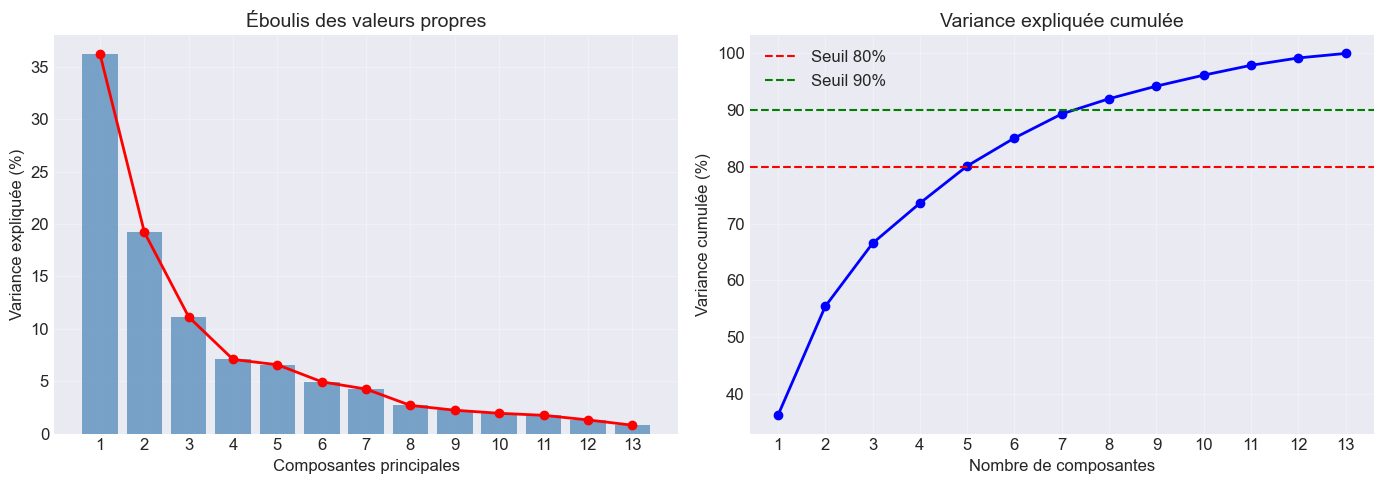

In [74]:
# Visualisation de la variance expliquée
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique des variances individuelles (éboulis des valeurs propres)
axes[0].bar(range(1, len(explained_variance)+1), explained_variance * 100, alpha=0.7, color='steelblue')
axes[0].plot(range(1, len(explained_variance)+1), explained_variance * 100, 'ro-', linewidth=2)
axes[0].set_xlabel('Composantes principales', fontsize=12)
axes[0].set_ylabel('Variance expliquée (%)', fontsize=12)
axes[0].set_title('Éboulis des valeurs propres', fontsize=14)
axes[0].set_xticks(range(1, len(explained_variance)+1))
axes[0].grid(True, alpha=0.3)

# Graphique de la variance cumulée
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100, 'bo-', linewidth=2, markersize=6)
axes[1].axhline(y=80, color='r', linestyle='--', label='Seuil 80%')
axes[1].axhline(y=90, color='g', linestyle='--', label='Seuil 90%')
axes[1].set_xlabel('Nombre de composantes', fontsize=12)
axes[1].set_ylabel('Variance cumulée (%)', fontsize=12)
axes[1].set_title('Variance expliquée cumulée', fontsize=14)
axes[1].set_xticks(range(1, len(cumulative_variance)+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

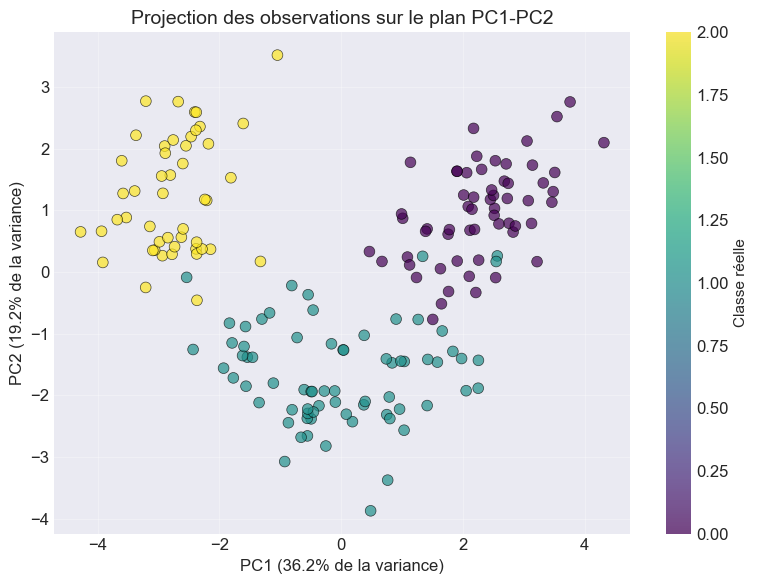

In [75]:
# Projection des observations sur les 2 premières composantes principales
plt.figure(figsize=(8, 6))

# Affichage des observations
scatter = plt.scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=y, cmap='viridis', s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}% de la variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}% de la variance)', fontsize=12)
plt.title('Projection des observations sur le plan PC1-PC2', fontsize=14)

# Ajout des couleurs pour les classes
cbar = plt.colorbar(scatter)
cbar.set_label('Classe réelle', fontsize=11)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

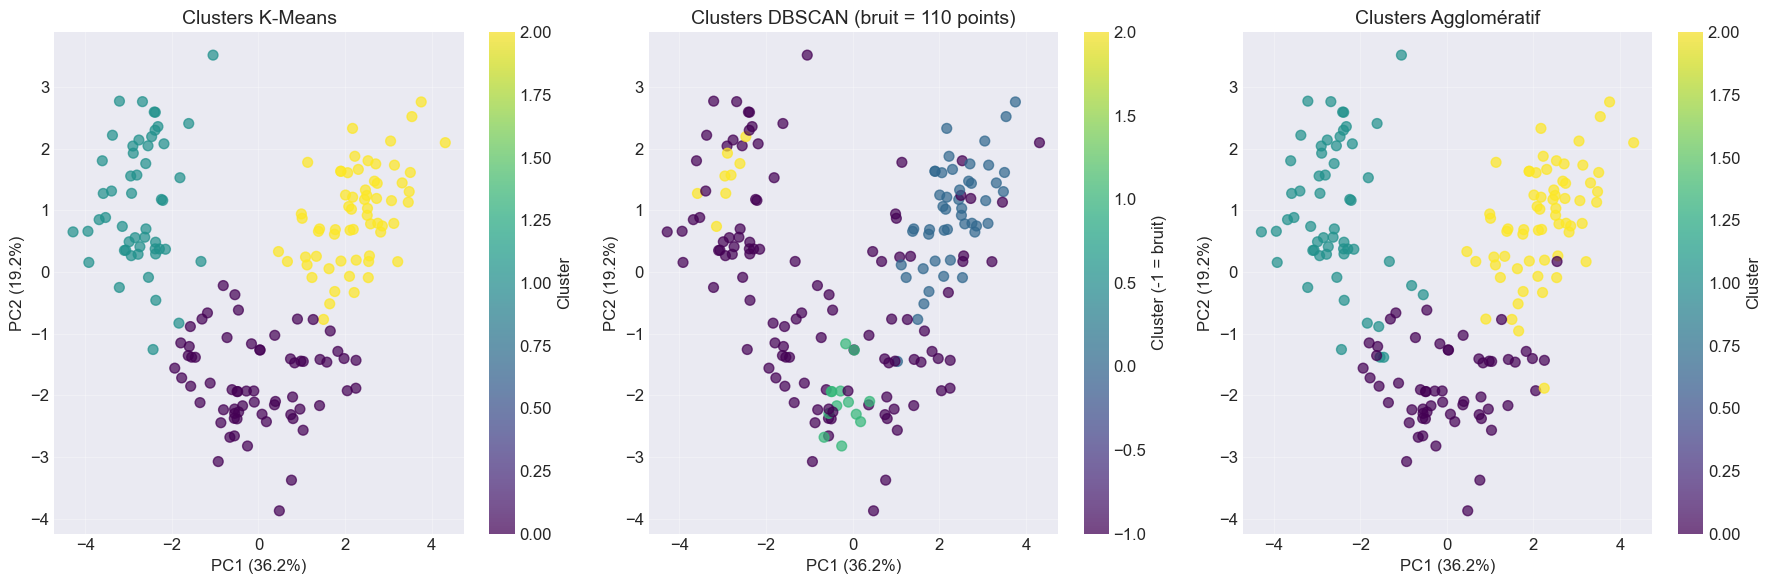

In [76]:
# Visualisation des regroupements obtenus avec les différentes méthodes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# K-Means
scatter1 = axes[0].scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('Clusters K-Means', fontsize=14)
axes[0].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN
scatter2 = axes[1].scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=dbscan_labels, cmap='viridis', s=50, alpha=0.7)
axes[1].set_title(f'Clusters DBSCAN (bruit = {n_noise_db} points)', fontsize=14)
axes[1].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster (-1 = bruit)')

# Agglomératif
scatter3 = axes[2].scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=agg_labels, cmap='viridis', s=50, alpha=0.7)
axes[2].set_title('Clusters Agglomératif', fontsize=14)
axes[2].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
axes[2].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[2], label='Cluster')

plt.tight_layout()
plt.show()

CONTRIBUTION DES VARIABLES AUX COMPOSANTES PRINCIPALES

Les 5 variables les plus contributives pour PC1 :
flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols            0.298533
Name: PC1, dtype: float64

Les 5 variables les plus contributives pour PC2 :
color_intensity    0.529996
alcohol            0.483652
proline            0.364903
ash                0.316069
magnesium          0.299634
Name: PC2, dtype: float64


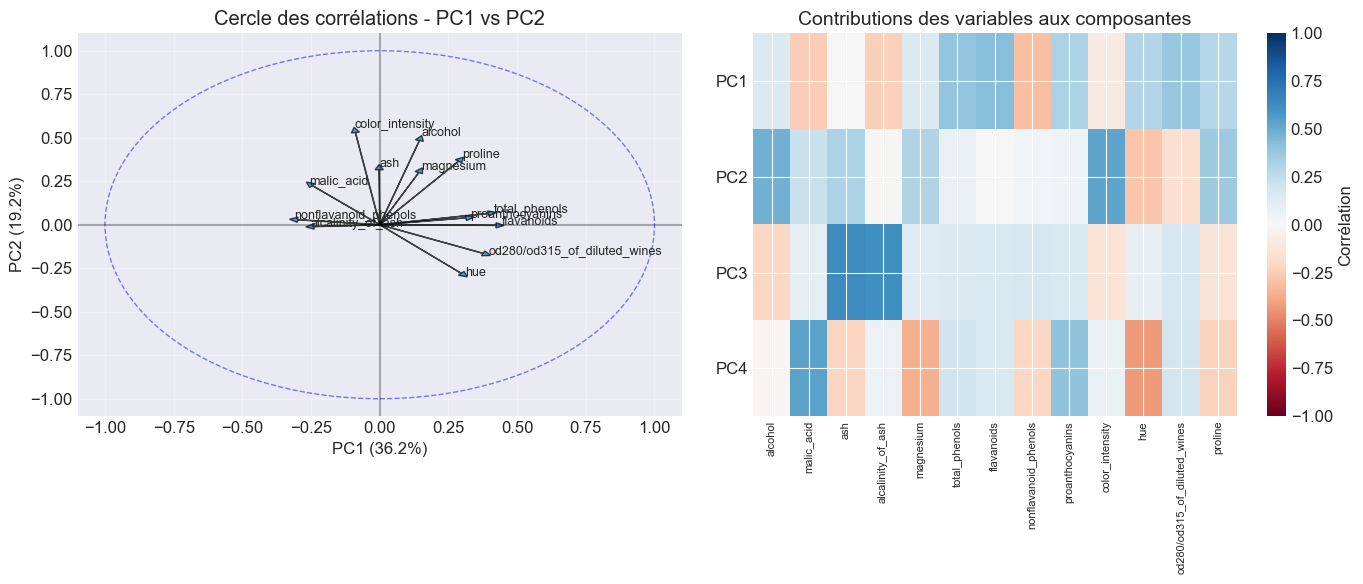

In [77]:
# Analyse des contributions des variables aux composantes principales
# Calcul des loadings (corrélation entre variables et composantes)
loadings = pca.components_.T

# Création d'un DataFrame pour visualiser les contributions
loadings_df = pd.DataFrame(loadings[:, :4],  # 4 premières composantes
                           index=feature_names,
                           columns=['PC1', 'PC2', 'PC3', 'PC4'])

print("=" * 60)
print("CONTRIBUTION DES VARIABLES AUX COMPOSANTES PRINCIPALES")
print("=" * 60)
print("\nLes 5 variables les plus contributives pour PC1 :")
print(loadings_df['PC1'].abs().sort_values(ascending=False).head(5))

print("\nLes 5 variables les plus contributives pour PC2 :")
print(loadings_df['PC2'].abs().sort_values(ascending=False).head(5))

# Visualisation des contributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cercle des corrélations pour PC1 et PC2
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
circle = plt.Circle((0, 0), 1, color='b', fill=False, linestyle='--', alpha=0.5)
axes[0].add_artist(circle)

for i, var in enumerate(feature_names):
    axes[0].arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.03, head_length=0.03, alpha=0.7)
    axes[0].text(loadings[i, 0]*1.05, loadings[i, 1]*1.05, var, fontsize=9)

axes[0].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
axes[0].set_title('Cercle des corrélations - PC1 vs PC2')
axes[0].set_xlim(-1.1, 1.1)
axes[0].set_ylim(-1.1, 1.1)
axes[0].grid(True, alpha=0.3)

# Heatmap des contributions
im = axes[1].imshow(loadings_df.iloc[:, :4].T, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(feature_names)))
axes[1].set_xticklabels(feature_names, rotation=90, fontsize=8)
axes[1].set_yticks(range(4))
axes[1].set_yticklabels(['PC1', 'PC2', 'PC3', 'PC4'])
axes[1].set_title('Contributions des variables aux composantes', fontsize=14)
plt.colorbar(im, ax=axes[1], label='Corrélation')

plt.tight_layout()
plt.show()

### Interpretation:
1. Cercle des Corrélations (PC1 vs PC2)
Le cercle des corrélations révèle que la PC1 est portée par la richesse phénolique (Flavonoïdes, Phénols totaux), séparant les vins selon leur structure antioxydante. La PC2 traduit plutôt la puissance du corps (Alcool, Intensité colorante), opposée à la teinte (Hue). La forte proximité des flèches phénoliques indique une corrélation élevée entre ces variables, confirmant que ces mesures chimiques évoluent conjointement dans les trois cultivars.

2. Heatmap des contributions
La heatmap confirme que la PC1 est l'axe de la structure phénolique, portée par de fortes contributions positives des Phénols totaux et des Flavonoïdes. La PC2 se définit par l'aspect organique et visuel, avec des scores élevés pour l'Alcool et l'Intensité colorante. Enfin, les composantes PC3 et PC4, bien que secondaires, isolent des variables minérales et acides comme les Cendres et l'Acide malique.

## Syhthèse de l'ACP:
Pour cette étude, nous avons choisi de retenir les trois premières composantes principales (PC1, PC2 et PC3), lesquelles capturent à elles seules 66,53 % de la variance totale du jeu de données. Ce choix constitue le meilleur compromis entre simplification de l'espace et conservation de l'information : la PC1 et la PC2 structurent l'essentiel des différences phénoliques et alcooliques entre les cultivars, tandis que la PC3 intègre les variations minérales (cendres). Bien que le seuil usuel de 80 % ne soit atteint qu'à la PC5, l'apport marginal de la PC4 (7,07 %) et de la PC5 (6,56 %) n'est pas jugé suffisant pour justifier une complexité accrue, ces dernières composantes étant potentiellement liées à du bruit ou à des variables chimiques secondaires peu discriminantes pour la séparation des trois groupes principaux.

## Application d'Isolation Forest

In [78]:
# Application d'Isolation Forest
iso_forest = IsolationForest(contamination=0.10, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_scaled)
# -1 = anomalie, 1 = normal

# Identification des points détectés comme anomalies
anomaly_indices = np.where(anomaly_labels == -1)[0]
n_anomalies = len(anomaly_indices)

print("=" * 60)
print("ISOLATION FOREST - DÉTECTION D'ANOMALIES")
print("=" * 60)

print(f"\nNombre total d'observations : {X_scaled.shape[0]}")
print(f"Points normaux : {np.sum(anomaly_labels == 1)}")
print(f"Points détectés comme anomalies : {n_anomalies}")
print(f"Pourcentage d'anomalies : {n_anomalies/len(X_scaled)*100:.1f}%")

print(f"\nIndices des observations atypiques :")
print(anomaly_indices.tolist())

ISOLATION FOREST - DÉTECTION D'ANOMALIES

Nombre total d'observations : 178
Points normaux : 160
Points détectés comme anomalies : 18
Pourcentage d'anomalies : 10.1%

Indices des observations atypiques :
[3, 13, 14, 18, 39, 50, 59, 69, 73, 95, 110, 115, 121, 124, 146, 150, 152, 158]


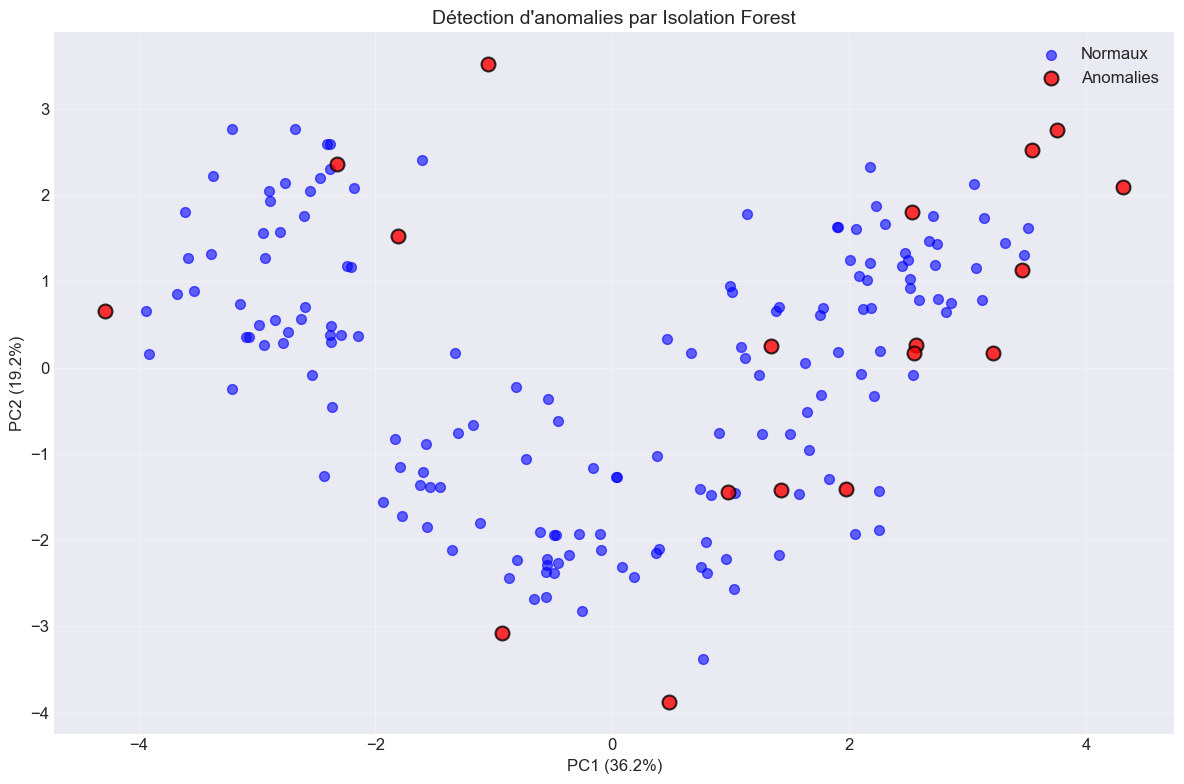

In [79]:
# Visualisation des anomalies
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

# Tracé des points normaux
normal_mask = anomaly_labels == 1
plt.scatter(X_pca_viz[normal_mask, 0], X_pca_viz[normal_mask, 1], 
            c='blue', label='Normaux', s=50, alpha=0.6)

# Tracé des anomalies
anomaly_mask = anomaly_labels == -1
plt.scatter(X_pca_viz[anomaly_mask, 0], X_pca_viz[anomaly_mask, 1], 
            c='red', label='Anomalies', s=100, alpha=0.8, edgecolors='black', linewidth=1.5)

plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Détection d\'anomalies par Isolation Forest', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
# Répartition des anomalies par classe réelle
print("\n" + "=" * 60)
print("RÉPARTITION DES ANOMALIES PAR CLASSE")
print("=" * 60)

for classe in range(3):
    classe_mask = (y == classe)
    anomalies_dans_classe = np.sum((anomaly_labels == -1) & classe_mask)
    total_classe = np.sum(classe_mask)
    print(f"Classe {classe} ({target_names[classe]}) : {anomalies_dans_classe}/{total_classe} anomalies ({anomalies_dans_classe/total_classe*100:.1f}%)")


RÉPARTITION DES ANOMALIES PAR CLASSE
Classe 0 (class_0) : 6/59 anomalies (10.2%)
Classe 1 (class_1) : 8/71 anomalies (11.3%)
Classe 2 (class_2) : 4/48 anomalies (8.3%)


### Discussion de la portée du résultat
Ce que révèle Isolation Forest
- Les 18 anomalies détectées (10,1% des données) sont des bservations que l'algorithme considère comme atypiques par rapport à l'ensemble du jeu de données.

#### Portée de ce résultat
1. Limites de la méthode: Le taux de contamination (10%) est arbitraire et détermine directement le nombre d'anomalies. Isolation Forest ne dit pas pourquoi une observation est anormale, seulement qu'elle l'est. Cependant, une observation peut être atypique sans être erronée

2. Interprétation possible
Ces anomalies pourraient correspondre à des vins ayant des profils chimiques inhabituels pour leur cultivar. Elles pourraient aussi représenter des erreurs de mesure ou des échantillons mal étiquetés Sans connaissance métier, on ne peut pas trancher.

3. Logique différente du clustering
Contrairement à DBSCAN qui rejette du bruit pour former des clusters, Isolation Forest ne produit aucune structure de regroupement. Sa finalité est la détection, non la classification ou la segmentation

Conclusion : Isolation Forest identifie des candidats potentiellement intéressants pour une inspection plus approfondie, mais ne peut pas, à lui seul, conclure à la nature réelle de ces anomalies.